<a href="https://colab.research.google.com/github/esinghbe23-ctrl/Multithreading/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import multiprocessing
import threading
import time
import pandas as pd
import matplotlib.pyplot as plt
import psutil

matrix_size = 500
num_matrices = 500

constant_matrix = np.random.randint(1, 10, (matrix_size, matrix_size))

num_cores = multiprocessing.cpu_count()
max_threads = 8

print("CPU Cores:", num_cores)
print("Testing threads from 1 to", max_threads)

CPU Cores: 2
Testing threads from 1 to 8


In [ ]:
thread_counts = []
execution_times = []
cpu_usages = []

def worker(start_idx, end_idx, random_matrices, constant_matrix, results):
    for i in range(start_idx, end_idx):
        result = np.dot(random_matrices[i], constant_matrix)
        results.append(result)
for num_threads in [1, 2, 3, 4, 5, 6, 7, 8]:
    print(f"\nRunning with {num_threads} thread(s)...")

    random_matrices = [
        np.random.randint(1, 10, (matrix_size, matrix_size))
        for _ in range(num_matrices)
    ]
    results = []
    threads = []
    matrices_per_thread = num_matrices // num_threads

    start_time = time.time()

    for t in range(num_threads):
        start_idx = t * matrices_per_thread

        if t == num_threads - 1:
            end_idx = num_matrices
        else:
            end_idx = (t + 1) * matrices_per_thread

        thread = threading.Thread(
            target=worker,
            args=(start_idx, end_idx, random_matrices, constant_matrix, results)
        )

        threads.append(thread)
        thread.start()

    for thread in threads:
        thread.join()

    end_time = time.time()

    total_time = (end_time - start_time) / 60
    cpu_usage = psutil.cpu_percent(interval=1)

    thread_counts.append(num_threads)
    execution_times.append(total_time)
    cpu_usages.append(cpu_usage)

    print(f"Time Taken: {total_time:.2f} minutes")
    print(f"CPU Usage: {cpu_usage}%")


Running with 1 thread(s)...
Time Taken: 1.52 minutes
CPU Usage: 3.5%

Running with 2 thread(s)...
Time Taken: 1.32 minutes
CPU Usage: 2.5%

Running with 3 thread(s)...
Time Taken: 1.36 minutes
CPU Usage: 56.7%

Running with 4 thread(s)...
Time Taken: 1.35 minutes
CPU Usage: 2.5%

Running with 5 thread(s)...
Time Taken: 1.37 minutes
CPU Usage: 1.5%

Running with 6 thread(s)...
Time Taken: 1.36 minutes
CPU Usage: 4.0%

Running with 7 thread(s)...
Time Taken: 1.37 minutes
CPU Usage: 53.0%

Running with 8 thread(s)...
Time Taken: 1.36 minutes
CPU Usage: 2.0%


In [ ]:
result_table = pd.DataFrame({
    'Threads': thread_counts,
    'Execution Time (min)': execution_times,
    'CPU Usage (%)': cpu_usages
})

print("\nResult Table:")
print(result_table)


Result Table:
   Threads  Execution Time (min)  CPU Usage (%)
0        1              1.524842            3.5
1        2              1.320872            2.5
2        3              1.360436           56.7
3        4              1.352788            2.5
4        5              1.370120            1.5
5        6              1.357070            4.0
6        7              1.374487           53.0
7        8              1.363543            2.0


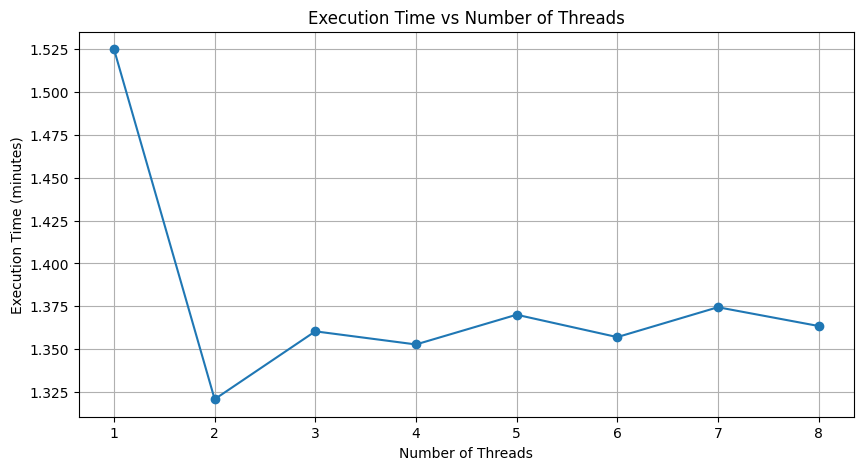

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(thread_counts, execution_times, marker='o')
plt.xlabel('Number of Threads')
plt.ylabel('Execution Time (minutes)')
plt.title('Execution Time vs Number of Threads')
plt.grid(True)
plt.show()

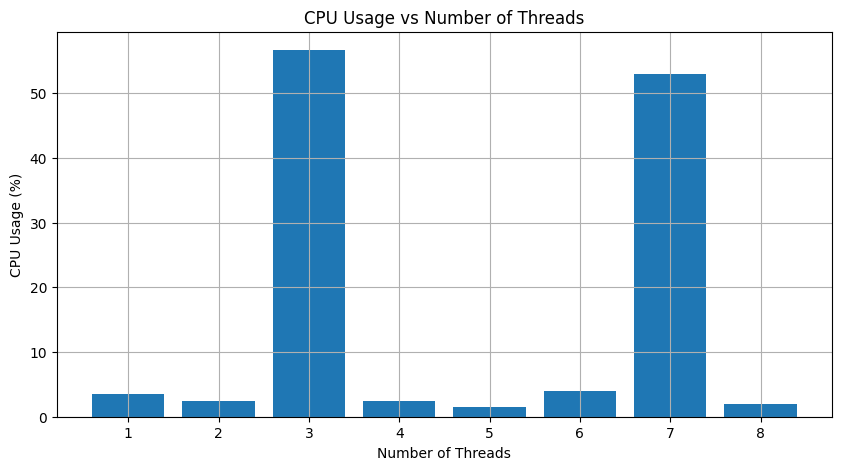

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(thread_counts, cpu_usages)
plt.xlabel('Number of Threads')
plt.ylabel('CPU Usage (%)')
plt.title('CPU Usage vs Number of Threads')
plt.grid(True)
plt.show()

In [ ]:
result_table.to_csv('matrix_thread_results.csv', index=False)
print('Results saved to matrix_thread_results.csv')

Results saved to matrix_thread_results.csv


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving matrix_thread_results.csv to matrix_thread_results (2).csv
